<a href="https://colab.research.google.com/github/GamelinAl/mbtrack2_examples/blob/main/coherent_synchrotron_radiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coherent Synchrotron Radiation (CSR) Wakefields

This notebook introduces the `FreeSpaceCSR` and `ParallelPlatesCSR` classes from `mbtrack2.impedance.csr`, which model the **coherent synchrotron radiation** (CSR) wakefield.

CSR arises when a relativistic electron bunch travels along a curved trajectory (e.g. in a dipole magnet). The electrons radiate coherently at wavelengths comparable to or shorter than the bunch length, and the radiation field acts back on the bunch as a collective, self-induced force. CSR is an important effect in storage rings operating at short bunch lengths or high current, and is a key driver of microwave instabilities.

Two models are provided:
- **`FreeSpaceCSR`**: free-space steady-state model (no shielding).
- **`ParallelPlatesCSR`**: steady-state model with shielding by perfectly conducting parallel plates (vacuum chamber).

Both classes inherit from `WakeField` and provide an `Impedance` and a `WakeFunction` component.

## References

[1] Faltens, A., & Laslett, L. J. (1973). Longitudinal coupling impedance of a stationary electron ring in a cylindrical geometry. *Part. Accel.*, 4, 151–157.

[2] Agoh, T. and K. Yokoya. "Calculation of coherent synchrotron radiation using mesh." *Phys. Rev. ST Accel. Beams* **7** (2004): 054403.

[3] E. L. Saldin, E. A. Schneidmiller, and M. V. Yurkov, "On the coherent radiation of an electron bunch moving in an arc of a circle", *Nucl. Instrum. Methods Phys. Res. A* **398**, 373 (1997).

[4] J. B. Murphy, S. Krinsky, and R. L. Gluckstern, "Longitudinal wakefield for an electron moving on a circular orbit", *Part. Accel.* **57**, 9 (1997).

In [ ]:
pip install mbtrack2

# Initialization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, pi

from mbtrack2 import WakeField, FreeSpaceCSR, ParallelPlatesCSR, Bunch, WakePotential

## Define a Synchrotron object

We use SOLEIL as an example storage ring. Both CSR classes require the `ring` object to access the Lorentz factor $\gamma$.

In [ ]:
from mbtrack2 import Electron, Optics, Synchrotron

h = 416          # Harmonic number.
L = 3.540969742590899e+02  # Ring circumference in [m].
E0 = 2.75e9      # Nominal energy in [eV].
particle = Electron()
ac = 4.16e-4     # Momentum compaction factor.
U0 = 1.171e6     # Energy loss per turn in [eV].
tau = np.array([6.56e-3, 6.56e-3, 3.27e-3])  # Damping times in [s].
tune = np.array([18.15687, 10.22824, 0.00502])  # Tunes.
emit = np.array([3.9e-9, 3.9e-9 * 0.01])  # Emittances in [m.rad].
sigma_0 = 15e-12    # RMS bunch length in [s].
sigma_delta = 1.025e-3  # RMS energy spread.
chro = [1.4, 2.3]   # Chromaticities.

beta = np.array([3, 1.3])    # Mean beta functions in [m].
alpha = np.array([0, 0])
dispersion = np.array([0, 0, 0, 0])
optics = Optics(local_beta=beta, local_alpha=alpha, local_dispersion=dispersion)

ring = Synchrotron(h, optics, particle, L=L, E0=E0, ac=ac, U0=U0, tau=tau,
                   emit=emit, tune=tune, sigma_delta=sigma_delta,
                   sigma_0=sigma_0, chro=chro)
print(f"Lorentz gamma: {ring.gamma:.1f}")
print(f"Natural RMS bunch length: {ring.sigma_0*c*1e3:.2f} mm ({ring.sigma_0*1e12:.1f} ps)")

Lorentz gamma: 5381.6
Natural RMS bunch length: 4.50 mm (15.0 ps)


# Free-space CSR: `FreeSpaceCSR`

## Physical model

In the **steady-state, free-space** approximation, a relativistic electron moving on a circular arc of radius $R$ induces a longitudinal wakefield on the bunch. This approximation is valid when:
- The transient effects at the entrance/exit of the bend are negligible (bend long compared to the formation length).
- The bunch is far from any conducting boundaries.
- The frequency range satisfies $\omega \ll 3\gamma^3 c / (2R)$.

## Impedance

The impedance is computed using Eq. (A10) of [2]:

$$Z_\parallel(\omega) = \frac{Z_0 L}{2\pi}\,\Gamma\!\left(\frac{2}{3}\right) \left(\frac{-i\omega}{3c R^2}\right)^{1/3}$$

where $Z_0 = \mu_0 c$ is the impedance of free space, $L$ is the length of the element, $R$ is the bending radius, and $\Gamma$ is the Euler gamma function.

## Wake function

The free-space CSR wake function is singular at $\tau = 0^-$. Two equivalent representations are implemented.

**Direct wake function** (Saldin et al. [3]):

$$W_\parallel(\tau) = -\frac{L}{\pi\varepsilon_0}\frac{\gamma^4}{R^2}\left[A + \frac{B}{C}\right], \quad \tau < 0$$

where $A$, $B$, $C$ are functions of the normalised time $\bar{s} = -\tau c\gamma^3/R$.

**Antiderivative method** (Murphy et al. [4]):

Because the direct wake function diverges as $\tau \to 0^-$, a numerically more accurate approach convolves the **antiderivative** $V(\tau) = \int_{-\infty}^{\tau} W_\parallel(\tau')\,d\tau'$ with the **derivative of the bunch profile** $\lambda'(\tau)$:

$$W_p(\tau) = \int_{-\infty}^{\infty} \lambda'(\tau') \, V(\tau - \tau') \, d\tau'$$

This is the default method used in mbtrack2 for `FreeSpaceCSR`. The antiderivative is stored as the `Wcsr` component of the `WakeField` (type `'csr'`), while the direct wake function is available via `LongitudinalWakeFunction` but is not added to the model by default.

## Creating a `FreeSpaceCSR` object

The main parameters are:
- `time`: time array where the antiderivative wake function is evaluated, in [s].
- `frequency`: frequency array for the impedance, in [Hz].
- `length`: effective length contributing to CSR, in [m].
- `radius`: dipole bending radius $R$, in [m].
- `ring`: the `Synchrotron` object (used for $\gamma$).

In [ ]:
R = 5.36         # Dipole bending radius in [m].
L_csr = ring.L   # Effective CSR length = ring circumference in [m].

# Time grid for tracking: spans the bunch (20 sigma_0 on each side).
t = np.linspace(-20 * ring.sigma_0, 20 * ring.sigma_0, 10_001)

# Frequency grid for the impedance up to 1 THz.
frequency = np.linspace(0, 1e12, 1000)  # in [Hz]

csr_fs = FreeSpaceCSR(time=t, frequency=frequency, length=L_csr, radius=R, ring=ring)
print(csr_fs)

WakeField None with components:
 [np.str_('Wcsr'), np.str_('Zlong')]


The `FreeSpaceCSR` object has two components:
- `Zlong`: the longitudinal impedance.
- `Wcsr`: the antiderivative of the wake function (type `'csr'`), used by `WakePotential`.

In [ ]:
csr_fs.components

array(['Wcsr', 'Zlong'], dtype='<U5')

## Plotting the impedance

Text(0.5, 1.0, 'Free-space CSR impedance')

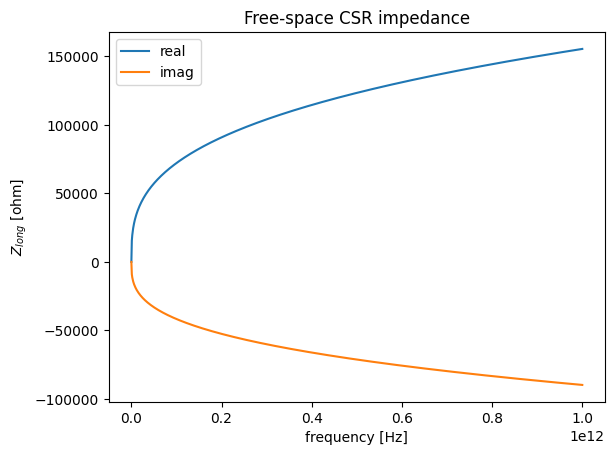

In [ ]:
%matplotlib inline
ax = csr_fs.Zlong.plot()
ax.set_title("Free-space CSR impedance")

## Plotting the wake function and its antiderivative

The wake function shape is resolved in the normalised coordinate $\mu = \frac{3\gamma^3}{2R}\,s$ (where $s = c\tau$ is the longitudinal position). To visualise it, a dedicated fine spatial grid is used — independent of the bunch-spanning time grid used for tracking.

Wake function zero crossing at mu = -2.7, i.e. s = 6.19e+01 pm


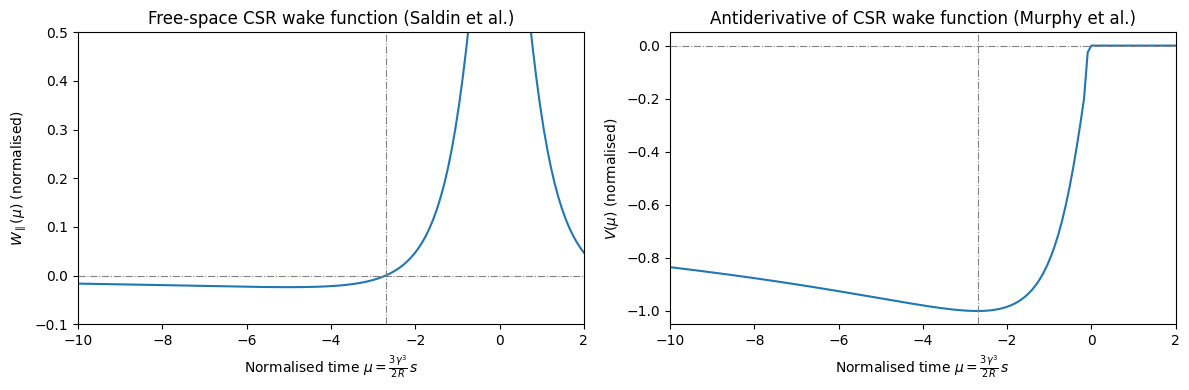

In [ ]:
# Dedicated spatial grid for wake function shape visualisation (in meters).
s_wf = np.linspace(-1e-8, 1e-8, 10_001)
mu = 3 * ring.gamma**3 / (2 * R) * s_wf  # normalised coordinate

# Direct wake function (Saldin et al.) — call the method with this fine grid.
W_direct = csr_fs.LongitudinalWakeFunction(time=s_wf / c)

# Antiderivative (Murphy et al.) — also called directly on the fine grid.
V_antiderivative = csr_fs.LongitudinalWakeAntiderivative(time=s_wf / c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

W_norm = np.nanmax(np.abs(W_direct[s_wf < 0]))
axes[0].plot(mu, W_direct / W_norm)
axes[0].set_xlim(-10, 2)
axes[0].set_ylim(-0.1, 0.5)
axes[0].axhline(0, color='gray', ls='-.', lw=0.8)
axes[0].axvline(-2.7, color='gray', ls='-.', lw=0.8)
axes[0].set_xlabel(r'Normalised time $\mu = \frac{3\gamma^3}{2R}\,s$')
axes[0].set_ylabel(r'$W_\parallel(\mu)$ (normalised)')
axes[0].set_title('Free-space CSR wake function (Saldin et al.)')

V_norm = np.nanmax(np.abs(V_antiderivative[s_wf < 0]))
axes[1].plot(mu, V_antiderivative / V_norm)
axes[1].set_xlim(-10, 2)
axes[1].axhline(0, color='gray', ls='-.', lw=0.8)
axes[1].axvline(-2.7, color='gray', ls='-.', lw=0.8)
axes[1].set_xlabel(r'Normalised time $\mu = \frac{3\gamma^3}{2R}\,s$')
axes[1].set_ylabel(r'$V(\mu)$ (normalised)')
axes[1].set_title('Antiderivative of CSR wake function (Murphy et al.)')

plt.tight_layout()

print(f"Wake function zero crossing at mu = -2.7, i.e. s = {1.8*R/ring.gamma**3*1e12:.2e} pm")

The wake function changes sign at $\mu \approx -2.7$ and diverges as $\mu \to 0^-$. The antiderivative $V(\mu)$ is smooth everywhere and reaches zero at $\mu = 0$, making it much better suited for numerical convolution.

# Parallel-plates CSR: `ParallelPlatesCSR`

## Physical model

When the beam pipe is modelled as two perfectly conducting parallel plates separated by a full-gap distance $h$, the CSR field is shielded at long wavelengths. This **shielding** suppresses the CSR emission below the **threshold frequency**:

$$f_{\rm th} = \frac{3c}{2\pi}\left(\frac{R}{h^3}\right)^{1/2}$$

Above threshold, the radiation spectrum is essentially the same as free space. Below threshold, the CSR power is strongly suppressed.

The `ParallelPlatesCSR` class provides:
- **Impedance** (`Zlong`): Eq. (A1) of [2] (Agoh-Yokoya sum formula), which includes both free-space and shielding contributions.
- **Shielding wake** (`Wlong`): Eqs. (5.21-5.22) of [4] (Murphy et al. G2 function), which contains only the shielding correction.
- **Free-space wake** (`Wcsr`): antiderivative of the free-space wake, automatically included by calling `FreeSpaceCSR` internally. This makes the time-domain model consistent with the frequency-domain impedance.

## Approximation used for the wake function

The parallel-plates wake function is computed via the normalised Green's function $G_2(\zeta)$, where $\zeta = -s / (2R\Delta^{3/2})$ and $\Delta = h/(2R)$:

$$G_2(\zeta) = \sum_{k=1}^{k_{\rm max}} \frac{2(-1)^{k+1}}{k^2} \frac{4Y_k^4(3 - Y_k^4)}{(1 + Y_k^4)^3}$$

where $Y_k(\zeta)$ is the real positive root of a characteristic polynomial (Eq. 5.18 of [4]). The sum is truncated at `k_max` terms. The amplitude coefficient is:

$$W_{\rm pp}(\tau) = -\frac{4L}{8\pi\varepsilon_0\, h^2}\, G_2\!\left(-c\tau\right)$$


## Creating a `ParallelPlatesCSR` object

In addition to the parameters of `FreeSpaceCSR`, `ParallelPlatesCSR` requires:
- `distance`: full-gap vertical separation between the plates $h$, in [m].
- `k_max` (optional): number of terms in the image-charge sum (default 100).

> Note: the impedance computation uses `mpmath` and can be slow for large frequency arrays. The wake function also uses a 2D root-finding loop and can take several seconds for a fine time grid.

In [ ]:
h_gap = 2*12.5e-3  # Full gap distance between the plates in [m].

# Time grid: use the same bunch-spanning grid as for FreeSpaceCSR.
# A coarser step is used here to keep computation time reasonable.
t_pp = np.arange(-5e-11, 5e-11, 1e-13)  # in [s]

csr_pp = ParallelPlatesCSR(
    time=t_pp,
    frequency=np.linspace(1, 2e12, 500),  # up to 1 THz
    length=L_csr,
    radius=R,
    distance=h_gap,
    ring=ring,
    k_max=25,
)
print(csr_pp)

WakeField None with components:
 [np.str_('Wcsr'), np.str_('Wlong'), np.str_('Zlong')]


The `ParallelPlatesCSR` object has three components:
- `Zlong`: the full longitudinal impedance (free space + shielding).
- `Wlong`: the shielding-only wake function (type `'long'`, standard convolution).
- `Wcsr`: the free-space CSR antiderivative (type `'csr'`, derivative convolution), automatically included for a complete time-domain model.


In [ ]:
csr_pp.components

array(['Wcsr', 'Wlong', 'Zlong'], dtype='<U5')

## Shielding threshold

In [ ]:
print(f"Shielding threshold: {csr_pp.threshold/1e9:.2f} GHz")
print(f"Delta = h/(2R) = {h_gap/(2*R):.4f}")

Shielding threshold: 83.84 GHz
Delta = h/(2R) = 0.0023


## Plotting the impedance

The real part of the parallel-plates impedance is suppressed below the shielding threshold compared to the free-space model.

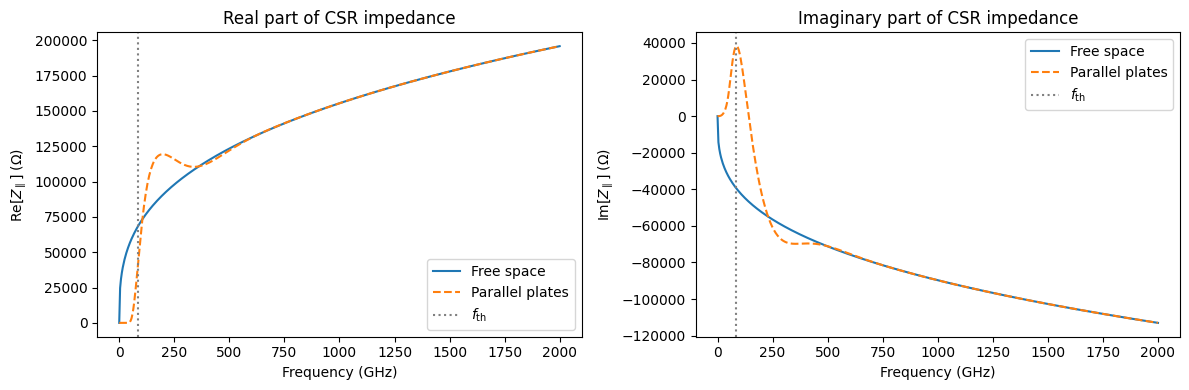

In [ ]:
# Recompute free-space impedance on the same frequency grid for comparison.
freq_compare = np.linspace(1, 2e12, 500)  # up to 1 THz
Z_fs = csr_fs.LongitudinalImpedance(freq_compare)
Z_pp = csr_pp.Zlong.data

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(freq_compare / 1e9, Z_fs.real, label='Free space', lw=1.5)
axes[0].plot(freq_compare / 1e9, Z_pp.real, label='Parallel plates', lw=1.5, ls='--')
axes[0].axvline(csr_pp.threshold / 1e9, color='gray', ls=':', label=r'$f_{\rm th}$')
axes[0].set_xlabel('Frequency (GHz)')
axes[0].set_ylabel(r'Re[$Z_\parallel$] ($\Omega$)')
axes[0].set_title('Real part of CSR impedance')
axes[0].legend()

axes[1].plot(freq_compare / 1e9, Z_fs.imag, label='Free space', lw=1.5)
axes[1].plot(freq_compare / 1e9, Z_pp.imag, label='Parallel plates', lw=1.5, ls='--')
axes[1].axvline(csr_pp.threshold / 1e9, color='gray', ls=':', label=r'$f_{\rm th}$')
axes[1].set_xlabel('Frequency (GHz)')
axes[1].set_ylabel(r'Im[$Z_\parallel$] ($\Omega$)')
axes[1].set_title('Imaginary part of CSR impedance')
axes[1].legend()

plt.tight_layout()

## Plotting the $G_2$ function and the parallel-plates wake function

The normalised Green's function $G_2(\zeta)$ characterises the shape of the shielding correction. It oscillates with decreasing amplitude around zero for $|\zeta| \gg 1$.

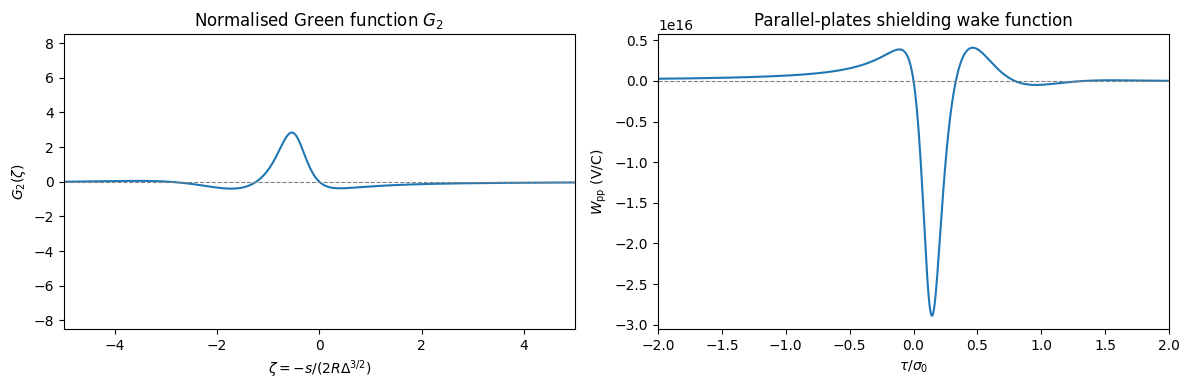

In [ ]:
delta = h_gap / (2 * R)
s_pp = t_pp * c
zeta = -s_pp / (2 * R * delta**(3/2))  # normalised coordinate

G2 = csr_pp._G2(s_pp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(zeta, G2)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(-8.5, 8.5)
axes[0].set_xlabel(r'$\zeta = -s/(2R\Delta^{3/2})$')
axes[0].set_ylabel(r'$G_2(\zeta)$')
axes[0].set_title('Normalised Green function $G_2$')

axes[1].plot(t_pp / ring.sigma_0, csr_pp.Wlong.data.real)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlim(-2, 2)
axes[1].set_xlabel(r'$\tau / \sigma_0$')
axes[1].set_ylabel(r'$W_{\rm pp}$ (V/C)')
axes[1].set_title('Parallel-plates shielding wake function')

plt.tight_layout()

# Using CSR wakefields in tracking

Both `FreeSpaceCSR` and `ParallelPlatesCSR` are used with the `WakePotential` class for single-bunch tracking. The `WakePotential` computes the wake potential by convolving the wake function with the bunch charge profile, then applies the resulting voltage kick to each macroparticle.

## Key difference: `Wcsr` vs `Wlong`

The two component types use different convolution algorithms:

| Component | `wake_type` | Algorithm |
|---|---|---|
| `Wcsr` | `"Wcsr"` | Convolves antiderivative $V(\tau)$ with $\lambda'(\tau)$ (derivative of profile) |
| `Wlong` | `"Wlong"` | Standard convolution of $W_{\rm pp}(\tau)$ with $\lambda(\tau)$ |

`ParallelPlatesCSR` has both components, so `WakePotential` will apply both convolutions each turn. The correct algorithm is triggered automatically by `WakePotential` based on the component type.


## Fine time grid for tracking

Both CSR models are rebuilt on a single common time grid spanning ±30 σ₀ with step σ₀/500. This grid is wide enough to cover the full bunch and fine enough to resolve the oscillatory shielding wake of `ParallelPlatesCSR`.

In [ ]:
dtau_track = ring.sigma_0 / 500
t_track = np.arange(-30 * ring.sigma_0, 30 * ring.sigma_0, dtau_track)

csr_fs = FreeSpaceCSR(time=t_track, frequency=frequency, length=L_csr, radius=R, ring=ring)
csr_pp = ParallelPlatesCSR(
    time=t_track,
    frequency=np.linspace(1, 2e12, 500),
    length=L_csr,
    radius=R,
    distance=h_gap,
    ring=ring,
    k_max=100,
)
print(f"Time grid: {len(t_track)} points, step = {dtau_track * 1e12:.2f} ps, span = ±{20 * ring.sigma_0 * 1e12:.0f} ps")

Time grid: 30000 points, step = 0.03 ps, span = ±300 ps


## Wake potential for `FreeSpaceCSR`

We first initialise a bunch at equilibrium, then compute the wake potential from a single call to `wp_fs.track` from the actual simulated bunch profile. We then compare it with the perfect-Gaussian bunch profile from `plot_gaussian_wake`.

In [ ]:
bunch_fs = Bunch(ring, mp_number=5_000_000, current=10e-3)
bunch_fs.init_gaussian()
wp_fs = WakePotential(ring, csr_fs, n_bin=200)
wp_fs.track(bunch_fs)

The `WakePotential` frequency cutoff (from `WakeFunction` time array definition and from `Bunch` binning) can be checked by using:

In [ ]:
print(f"Max frequency taken into account in tracking: {wp_fs.wakepotential_max_frequency*1e-9:.2f} GHz")

Max frequency taken into account in tracking: 614.23 GHz


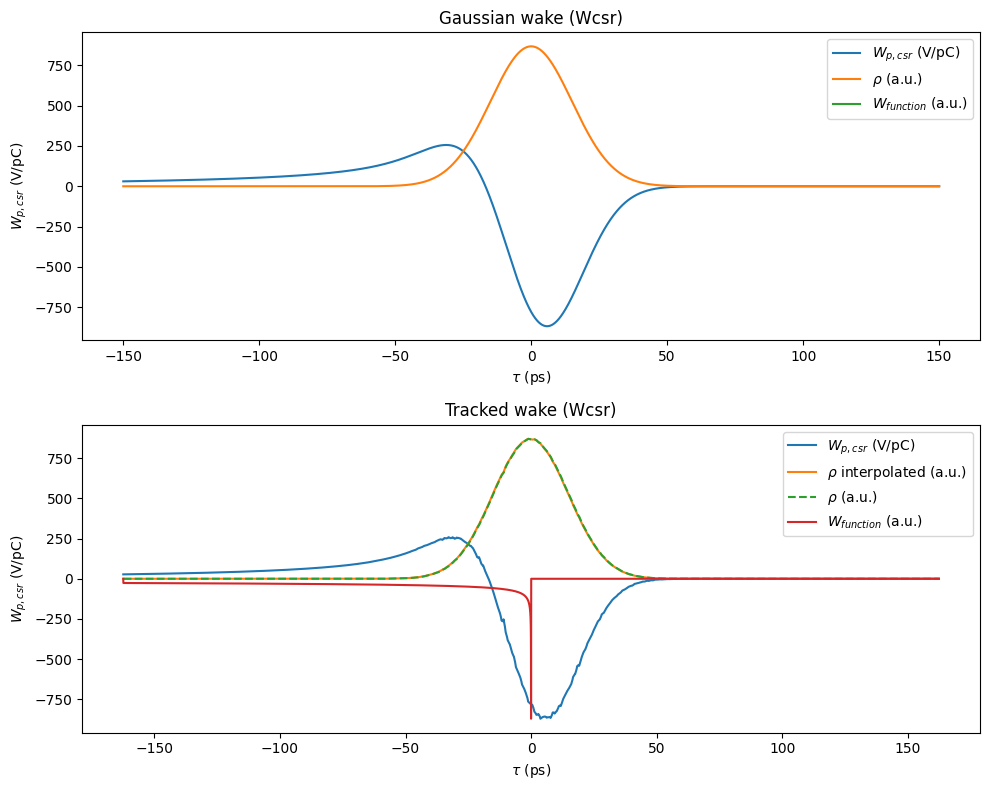

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

wp_fs.plot_gaussian_wake(ring.sigma_0, wake_type="Wcsr", ax=axes[0])
axes[0].set_title("Gaussian wake (Wcsr)")

wp_fs.plot_last_wake("Wcsr", ax=axes[1])
axes[1].set_title("Tracked wake (Wcsr)")

plt.tight_layout()

The typical free space CSR wake potential shows a net energy loss at the bunch tail and an energy gain at the head.

### Comparison with the analytic Gaussian solution

For a perfectly Gaussian bunch in the free-space, steady-state CSR regime, the wake potential has a closed-form expression in terms of the parabolic cylinder function (Saldin-Schneidmiller-Yurkov):

$$W_p(s) = -\frac{1}{4\pi\varepsilon_0}\,\sqrt{\frac{2}{\pi}}\,\frac{\Gamma(2/3)}{(3R^2\sigma^4)^{1/3}}\,\exp\!\left(-\frac{s^2}{4\sigma^2}\right)\,D_{1/3}\!\left(-\frac{s}{\sigma}\right)$$

where $s = c\tau$, $R$ is the bending radius, $\sigma$ is the RMS bunch length in [m], and $D_\nu$ is the parabolic cylinder function. This expression gives the wake potential per unit dipole length, so it must be multiplied by `ring.L` (the effective CSR length used in `FreeSpaceCSR`) to be compared with the mbtrack2 numerical result.

In [ ]:
from scipy.special import pbdv, gamma
from scipy.constants import epsilon_0

def get_gaussian_csr_wakepotential(s, rho, sigma):
    coeff = -1/(4*pi*epsilon_0) * np.sqrt(2/pi) / (3 * rho**2 * sigma**4)**(1/3)
    return coeff * gamma(2/3) * np.exp(-.25*(s/sigma)**2) * pbdv(1/3, -s/sigma)[0]

t_analytic = np.linspace(-10 * ring.sigma_0, 10 * ring.sigma_0, 2902)
Wp_analytic = get_gaussian_csr_wakepotential(c * t_analytic, R, ring.sigma_0 * c) * ring.L

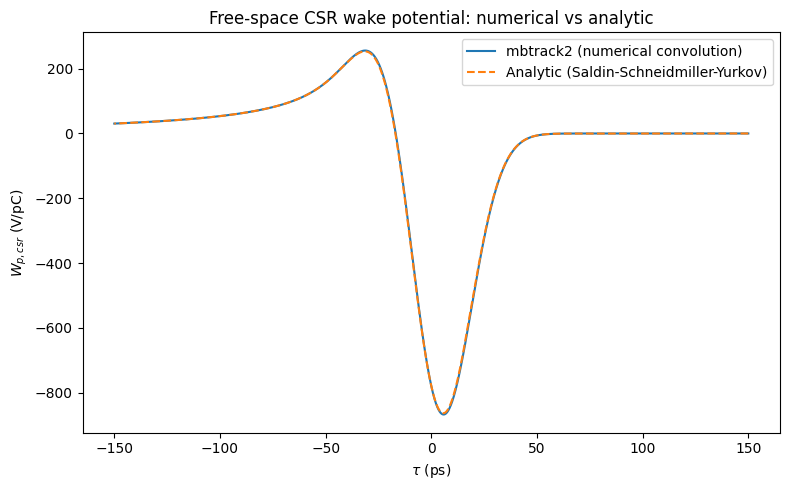

In [ ]:
tau0_num, _, Wp_num, _, _ = wp_fs.get_gaussian_wakepotential(ring.sigma_0, "Wcsr")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau0_num * 1e12, Wp_num * 1e-12, label="mbtrack2 (numerical convolution)")
ax.plot(-t_analytic * 1e12, Wp_analytic * 1e-12, ls='--', label="Analytic (Saldin-Schneidmiller-Yurkov)")
ax.set_xlabel(r"$\tau$ (ps)")
ax.set_ylabel(r"$W_{p,csr}$ (V/pC)")
ax.set_title("Free-space CSR wake potential: numerical vs analytic")
ax.legend()
plt.tight_layout()

## Wake potential for `ParallelPlatesCSR`

### Fully shielded regime

Since `ParallelPlatesCSR` contains both `Wlong` and `Wcsr`, we can retrieve and plot each contribution separately.

Top row: Gaussian predictions. Bottom row: wake potentials from `plot_last_wake` after a single `wp_pp.track` call.

In [ ]:
bunch_pp = Bunch(ring, mp_number=5_000_000, current=10e-3)
bunch_pp.init_gaussian()
wp_pp = WakePotential(ring, csr_pp, n_bin=128)
wp_pp.track(bunch_pp)

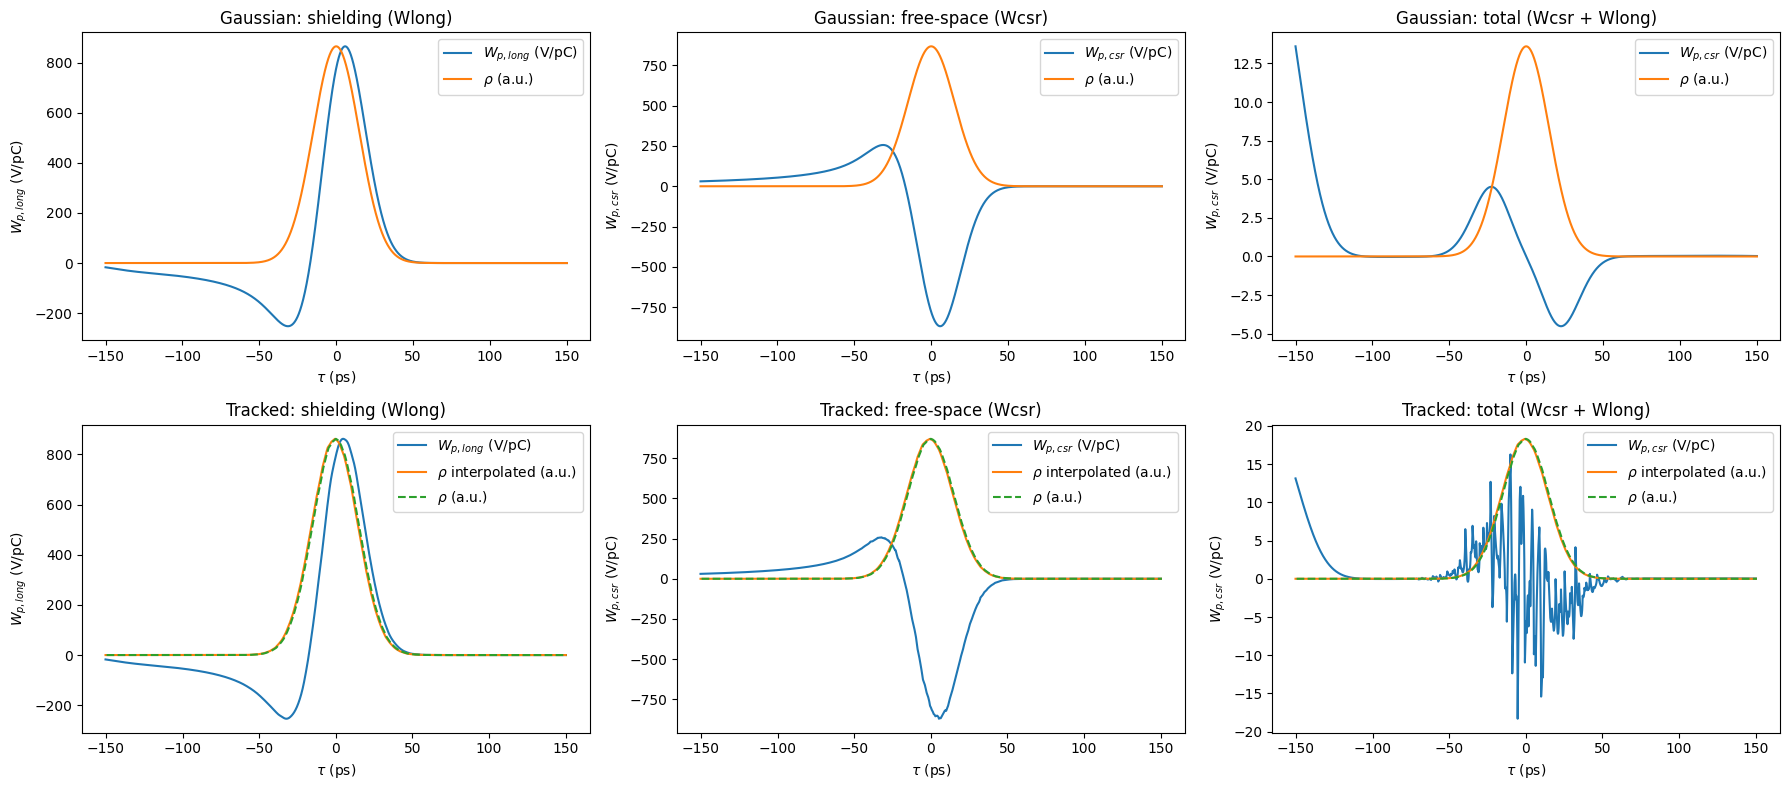

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

wp_pp.plot_gaussian_wake(ring.sigma_0, wake_type="Wlong", plot_wake_function=False, ax=axes[0, 0])
axes[0, 0].set_title("Gaussian: shielding (Wlong)")

wp_pp.plot_gaussian_wake(ring.sigma_0, wake_type="Wcsr", plot_wake_function=False, ax=axes[0, 1])
axes[0, 1].set_title("Gaussian: free-space (Wcsr)")

wp_pp.plot_gaussian_wake(ring.sigma_0, wake_type="Wcsr", plot_full_csr_wake=True, plot_wake_function=False, ax=axes[0, 2])
axes[0, 2].set_title("Gaussian: total (Wcsr + Wlong)")

wp_pp.plot_last_wake("Wlong", plot_wake_function=False, ax=axes[1, 0])
axes[1, 0].set_title("Tracked: shielding (Wlong)")

wp_pp.plot_last_wake("Wcsr", plot_wake_function=False, ax=axes[1, 1])
axes[1, 1].set_title("Tracked: free-space (Wcsr)")

wp_pp.plot_last_wake("Wcsr", plot_full_csr_wake=True, plot_wake_function=False, ax=axes[1, 2])
axes[1, 2].set_title("Tracked: total (Wcsr + Wlong)")

plt.tight_layout()

As it is visible in tracking total wake for `Wcsr` + `Wlong`, the `ParallelPlateCSR` can be **quite sensitive to noise** when in the shielded regime.
This is due to:
+ The `Wcsr` dependancy on the derivative of bunch profile.
+ The near perfect cancellation of `Wcsr` and `Wlong`.

In that case, a **convergence study needs to be done** to check the influence of numerical noise on beam dynamics results.

### Partialy shielded regime

If the bunch length is reduced, the beam frequency reached is increased and the effect of numerical noise is reduced.

In [ ]:
ring.sigma_0 = 5e-12

In [ ]:
bunch_pp = Bunch(ring, mp_number=5_000_000, current=10e-3)
bunch_pp.init_gaussian()
wp_pp = WakePotential(ring, csr_pp, n_bin=128)
wp_pp.track(bunch_pp)

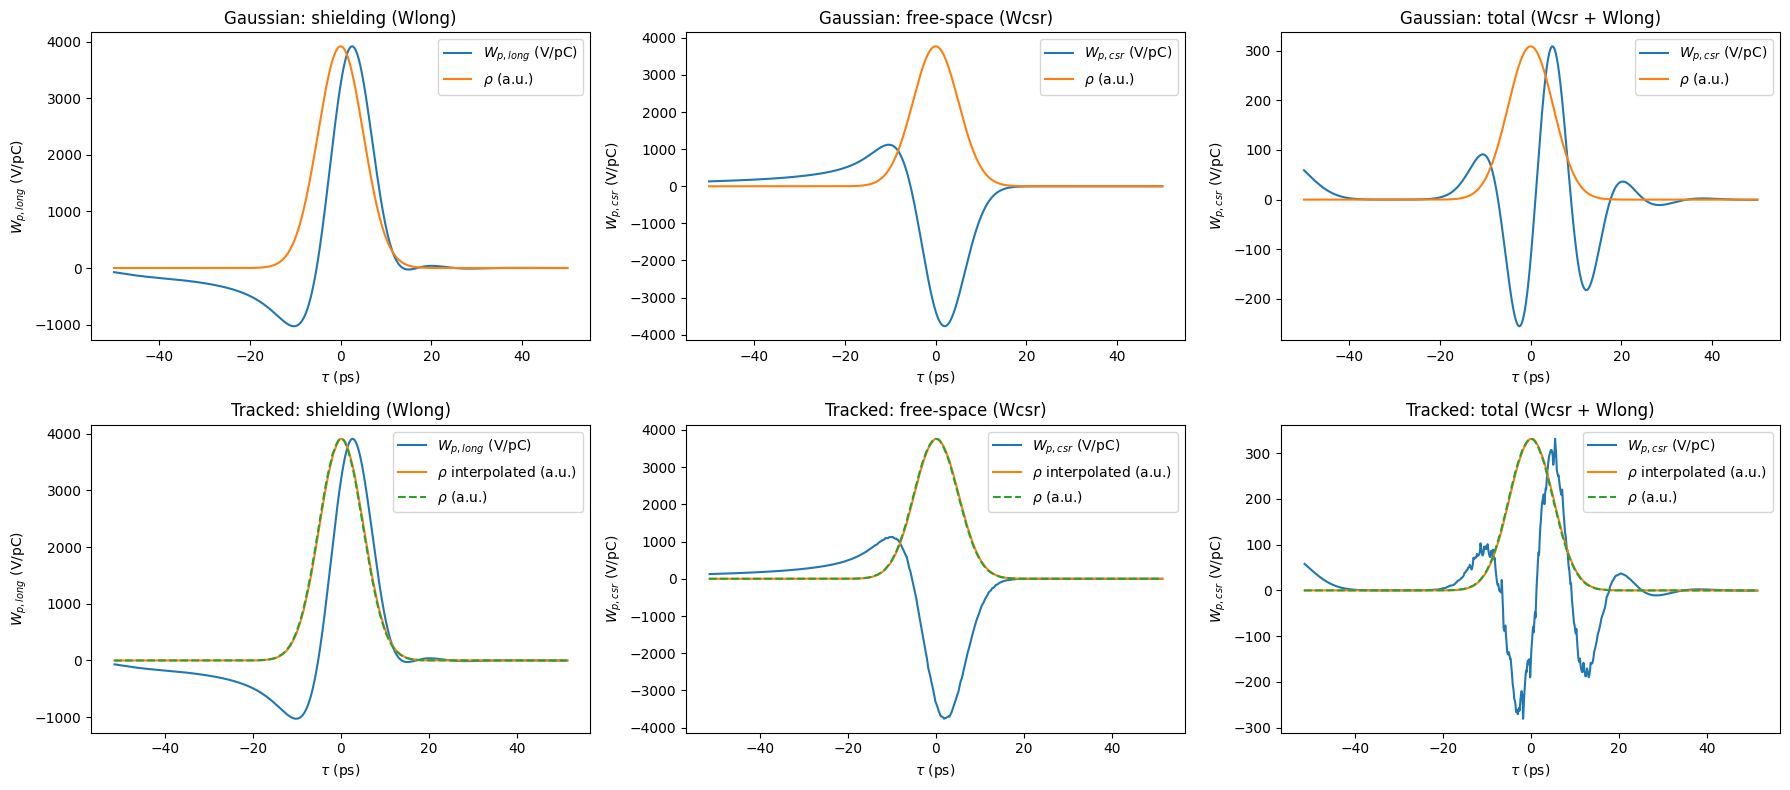

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

wp_pp.plot_gaussian_wake(ring.sigma_0, wake_type="Wlong", plot_wake_function=False, ax=axes[0, 0])
axes[0, 0].set_title("Gaussian: shielding (Wlong)")

wp_pp.plot_gaussian_wake(ring.sigma_0, wake_type="Wcsr", plot_wake_function=False, ax=axes[0, 1])
axes[0, 1].set_title("Gaussian: free-space (Wcsr)")

wp_pp.plot_gaussian_wake(ring.sigma_0, wake_type="Wcsr", plot_full_csr_wake=True, plot_wake_function=False, ax=axes[0, 2])
axes[0, 2].set_title("Gaussian: total (Wcsr + Wlong)")

wp_pp.plot_last_wake("Wlong", plot_wake_function=False, ax=axes[1, 0])
axes[1, 0].set_title("Tracked: shielding (Wlong)")

wp_pp.plot_last_wake("Wcsr", plot_wake_function=False, ax=axes[1, 1])
axes[1, 1].set_title("Tracked: free-space (Wcsr)")

wp_pp.plot_last_wake("Wcsr", plot_full_csr_wake=True, plot_wake_function=False, ax=axes[1, 2])
axes[1, 2].set_title("Tracked: total (Wcsr + Wlong)")

plt.tight_layout()

# Summary

| | `FreeSpaceCSR` | `ParallelPlatesCSR` |
|---|---|---|
| **Model** | Steady-state, no boundaries | Steady-state + perfectly conducting plates |
| **Impedance formula** | Agoh-Yokoya Eq. (A10) | Agoh-Yokoya Eq. (A1), sum over image charges |
| **Zlong** | Yes | Yes (free space + shielding) |
| **Wlong** | No | Yes (shielding correction, $G_2$ function) |
| **Wcsr** | Yes (antiderivative $V(\tau)$) | Yes (automatically included via `FreeSpaceCSR`) |
| **Convolution for Wcsr** | $V(\tau) \star \lambda'(\tau)$ | $V(\tau) \star \lambda'(\tau)$ |
| **Convolution for Wlong** | N/A | $W_{\rm pp}(\tau) \star \lambda(\tau)$ |
| **Shielding** | None | Suppressed below $f_{\rm th}$ |
| **Complete time-domain model** | Yes | Yes |
